In [36]:
# ==============================================================================
# PREDICTIVE ANALYTICS LAB EXAM - 2
# TASK: Binary Classification (Feature1, Feature2 -> Target)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

Cleaned dataset size: 999


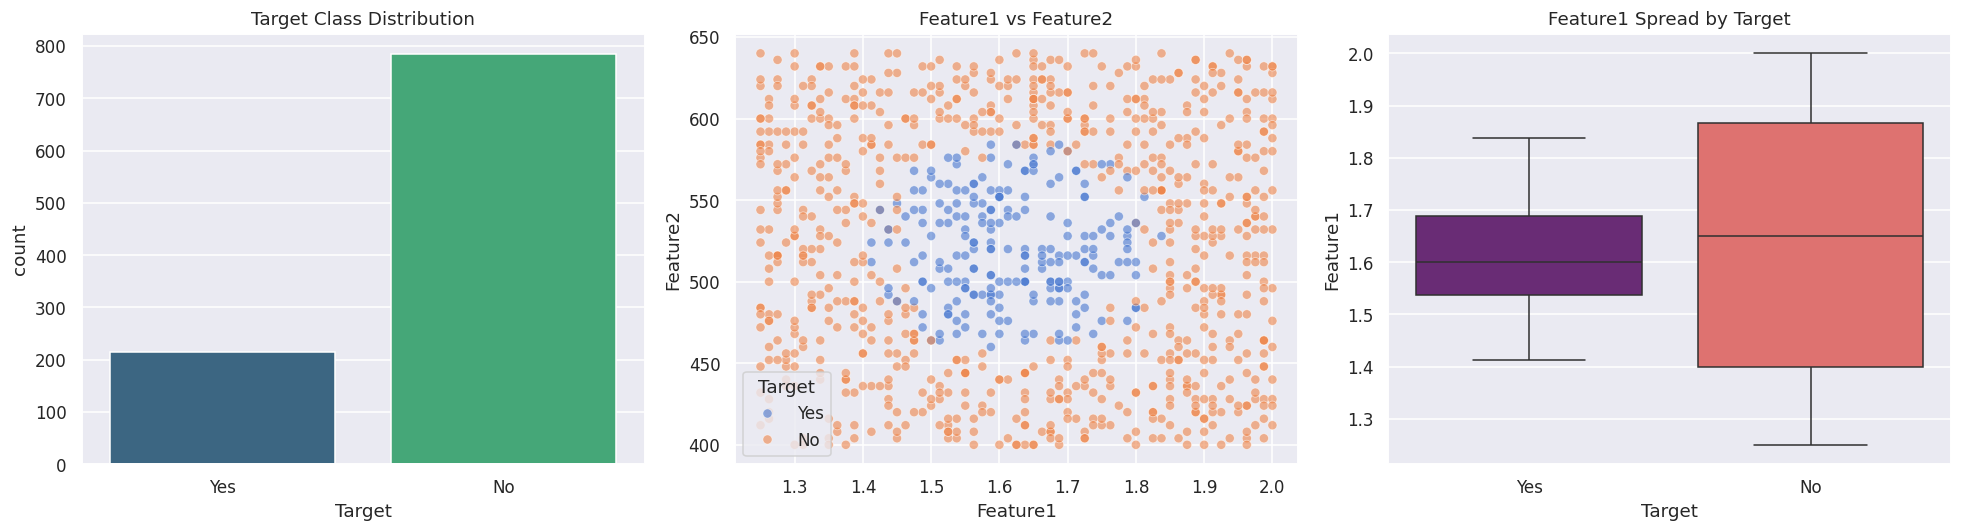

In [38]:
# ------------------------------------------------------------------------------
# 1. EXPLORATORY DATA ANALYSIS (EDA) [7 Marks]
# ------------------------------------------------------------------------------

# Load dataset (Note: Adjust path if your folder name is different)
file_path = '/content/new_data/Lab_Exam_binary_classification_dataset.csv'
dataset = pd.read_csv(file_path)

# Data Cleaning: Handling nulls and outliers
dataset = dataset.dropna(subset=['Target']).copy()

# Outlier removal using IQR for Feature1
q1, q3 = dataset['Feature1'].quantile([0.25, 0.75])
iqr_val = q3 - q1
upper_limit = q3 + 1.5 * iqr_val
dataset = dataset[dataset['Feature1'] <= upper_limit].copy()

print(f"Cleaned dataset size: {len(dataset)}")

# Visualizing distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Class Balance
sns.countplot(data=dataset, x='Target', ax=axes[0], palette='viridis')
axes[0].set_title('Target Class Distribution')

# Plot 2: Feature relationship
sns.scatterplot(data=dataset, x='Feature1', y='Feature2', hue='Target', ax=axes[1], alpha=0.6)
axes[1].set_title('Feature1 vs Feature2')

# Plot 3: Boxplots for outlier verification
sns.boxplot(data=dataset, x='Target', y='Feature1', ax=axes[2], palette='magma')
axes[2].set_title('Feature1 Spread by Target')

plt.tight_layout()
plt.show()

In [40]:
#2. CLASSIFICATION MODEL BUILDING
# ------------------------------------------------------------------------------

# Feature and Target preparation
dataset['Target_Code'] = dataset['Target'].map({'Yes': 1, 'No': 0})
X = dataset[['Feature1', 'Feature2']].values
y = dataset['Target_Code'].values

# Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Pipeline for Scaling + Logistic Regression
# We use 'class_weight=balanced' to handle the moderate imbalance automatically
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, class_weight='balanced', random_state=42))
])

# Training
clf_pipeline.fit(X_train, y_train)

# Cross-Validation
cv_scores = cross_val_score(clf_pipeline, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV Accuracy: 0.5275 (+/- 0.0531)


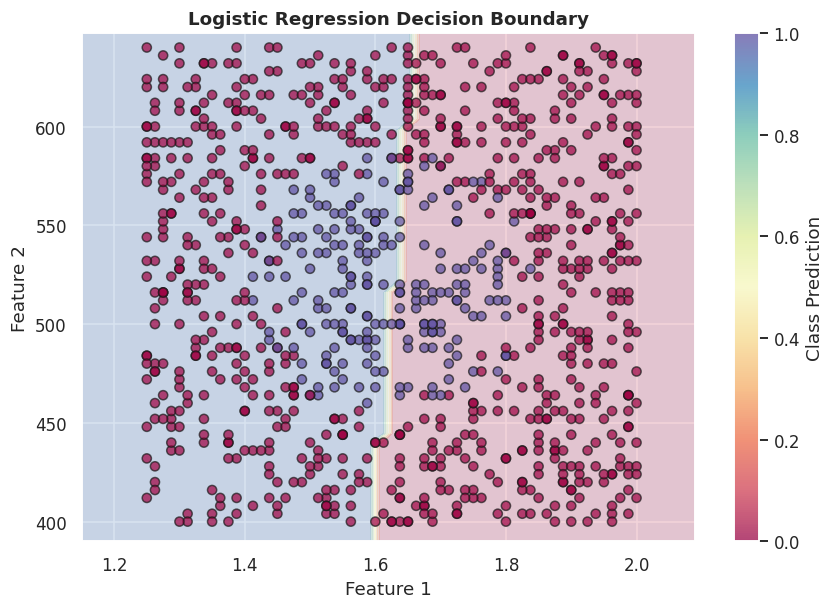

In [41]:
# ------------------------------------------------------------------------------
# 3. DECISION BOUNDARY VISUALIZATION [4 Marks]
# ------------------------------------------------------------------------------

def display_boundary(X_data, y_data, pipeline, title):
    h = 0.02
    x_min, x_max = X_data[:, 0].min() - 0.1, X_data[:, 0].max() + 0.1
    y_min, y_max = X_data[:, 1].min() - 10, X_data[:, 1].max() + 10

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, (y_max-y_min)/((x_max-x_min)/h)))

    Z = pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, Z, alpha=0.2, cmap='Spectral')
    scatter = plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, edgecolors='k', cmap='Spectral', alpha=0.7)
    plt.title(title, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Class Prediction')
    plt.show()

display_boundary(X, y, clf_pipeline, "Logistic Regression Decision Boundary")


=== PERFORMANCE REPORT ===
Test Accuracy: 0.5550
ROC-AUC Score: 0.5392

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.53      0.65       157
           1       0.27      0.65      0.39        43

    accuracy                           0.56       200
   macro avg       0.56      0.59      0.52       200
weighted avg       0.72      0.56      0.59       200



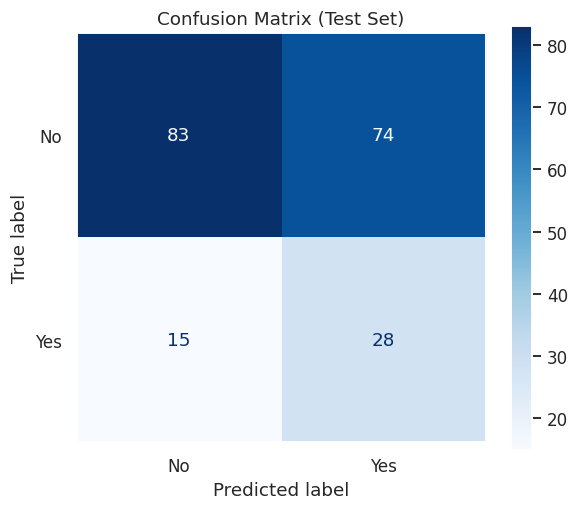

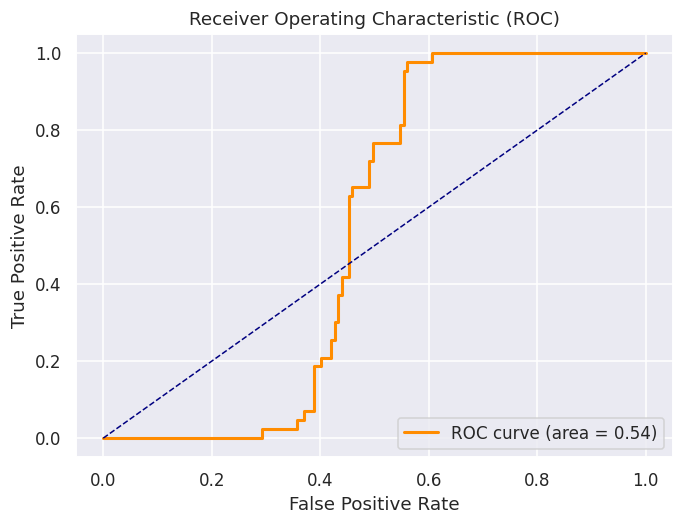

In [42]:
# ------------------------------------------------------------------------------
# 4. PERFORMANCE EVALUATION [6 Marks]
# ------------------------------------------------------------------------------

y_pred = clf_pipeline.predict(X_test)
y_prob = clf_pipeline.predict_proba(X_test)[:, 1]

print("\n=== PERFORMANCE REPORT ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visual
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'], cmap='Blues', ax=ax)
plt.title('Confusion Matrix (Test Set)')
plt.grid(False)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()